In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/drive/MyDrive/PDM/Dataset/Student_performance_10k.csv')

# rapikan kolom
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print(df.columns)
df.head()

Index(['roll_no', 'gender', 'race_ethnicity', 'parental_level_of_education',
       'lunch', 'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'science_score', 'total_score', 'grade'],
      dtype='object')


,roll_no,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,science_score,total_score,grade
0,std-01,male,group D,some college,1.0,1.0,89,38.0,85.0,26.0,238.0,C
1,std-02,male,group B,high school,1.0,0.0,65,100.0,67.0,96.0,328.0,A
2,std-03,male,group C,master's degree,1.0,0.0,10,99.0,97.0,58.0,264.0,B
3,std-04,male,group D,some college,1.0,1.0,22,51.0,41.0,84.0,198.0,D
4,std-05,male,group C,some college,0.0,1.0,26,58.0,64.0,65.0,213.0,C


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   roll_no                      9999 non-null   object 
 1   gender                       9982 non-null   object 
 2   race_ethnicity               9977 non-null   object 
 3   parental_level_of_education  9978 non-null   object 
 4   lunch                        9976 non-null   float64
 5   test_preparation_course      9977 non-null   float64
 6   math_score                   9976 non-null   object 
 7   reading_score                9975 non-null   float64
 8   writing_score                9976 non-null   float64
 9   science_score                9977 non-null   float64
 10  total_score                  9981 non-null   float64
 11  grade                        9997 non-null   object 
dtypes: float64(6), object(6)
memory usage: 937.6+ KB


,0
roll_no,1
gender,18
race_ethnicity,23
parental_level_of_education,22
lunch,24
test_preparation_course,23
math_score,24
reading_score,25
writing_score,24
science_score,23


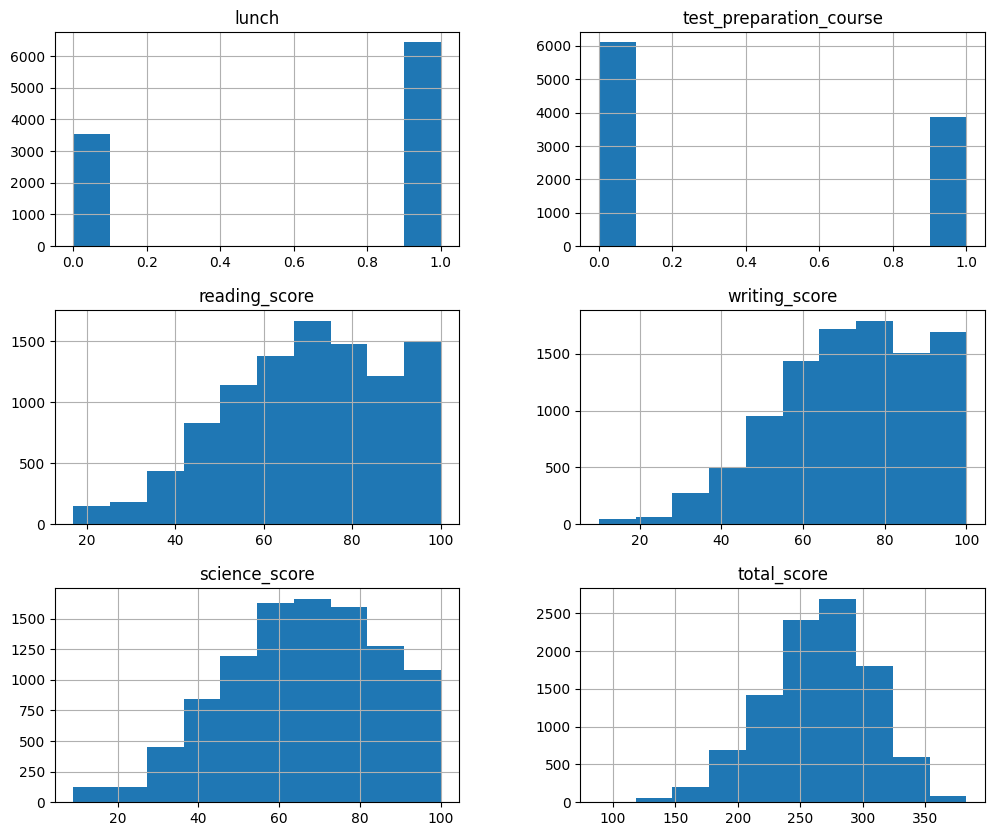

In [5]:
df.hist(figsize=(12,10))
plt.show()

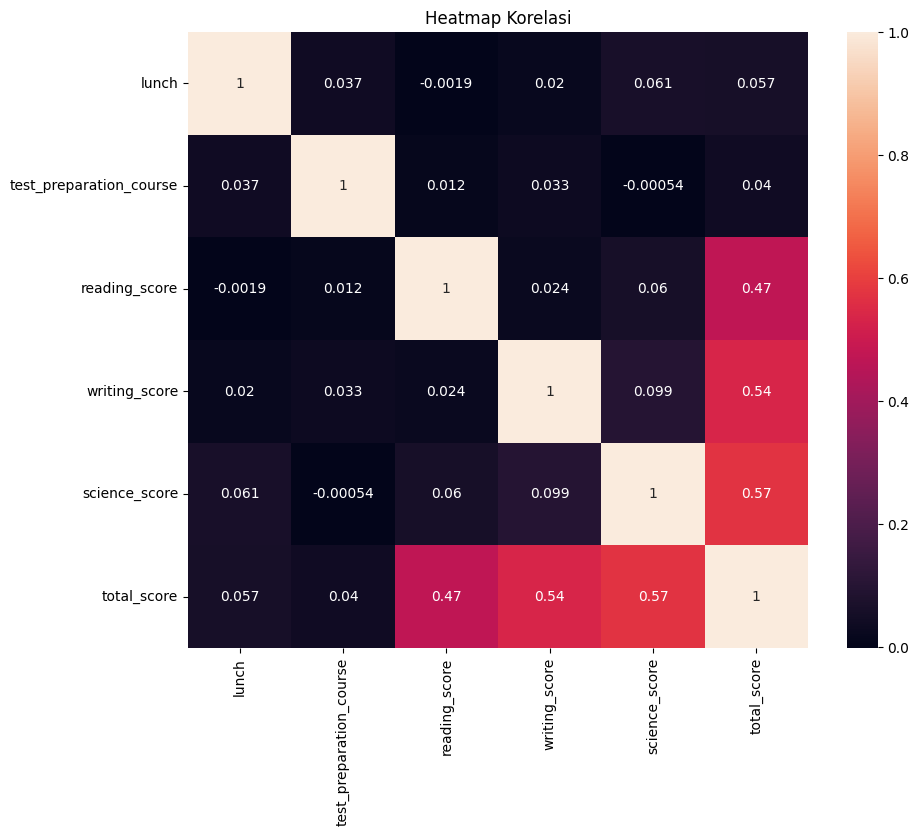

In [6]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Heatmap Korelasi")
plt.show()

In [7]:
# deteksi kolom nilai
score_cols = [col for col in df.columns if 'score' in col or 'math' in col or 'reading' in col or 'writing' in col]

# convert ke numeric (fix error)
for col in score_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# buat average
df['average_score'] = df[score_cols].mean(axis=1)

# isi missing
df['average_score'] = df['average_score'].fillna(df['average_score'].mean())

In [8]:
threshold = df['average_score'].mean()

df['admission_status'] = df['average_score'].apply(
    lambda x: 1 if x >= threshold else 0
)

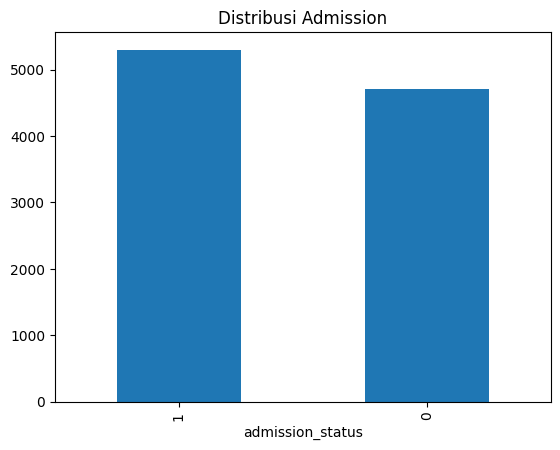

In [9]:
df['admission_status'].value_counts().plot(kind='bar')
plt.title("Distribusi Admission")
plt.show()

In [10]:
df_clean = df.copy()

# numerik
for col in df_clean.select_dtypes(include=np.number):
    df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

# kategorikal
for col in df_clean.select_dtypes(include='object'):
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_clean.select_dtypes(include='object'):
    df_clean[col] = le.fit_transform(df_clean[col])

In [12]:
from sklearn.model_selection import train_test_split

X = df_clean.drop('admission_status', axis=1)
y = df_clean['admission_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (8000, 13)
Test: (2000, 13)


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       939
           1       1.00      1.00      1.00      1061

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [21]:
results = {}

for depth in [3, 5, 7]:
    for n in [100, 200, 300]:

        model = XGBClassifier(
            max_depth=int(depth),
            n_estimators=int(n),
            learning_rate=0.05,
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42
        )

        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)

        results[f"depth={depth}, n={n}"] = acc

# ubah ke tabel
df_results = pd.DataFrame(results.items(), columns=['Parameter', 'Accuracy'])
df_results = df_results.sort_values(by='Accuracy', ascending=False)

df_results

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:16:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:16:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:16:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:16:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

,Parameter,Accuracy
0,"depth=3, n=100",1.0
1,"depth=3, n=200",1.0
2,"depth=3, n=300",1.0
3,"depth=5, n=100",1.0
4,"depth=5, n=200",1.0
5,"depth=5, n=300",1.0
6,"depth=7, n=100",1.0
7,"depth=7, n=200",1.0
8,"depth=7, n=300",1.0


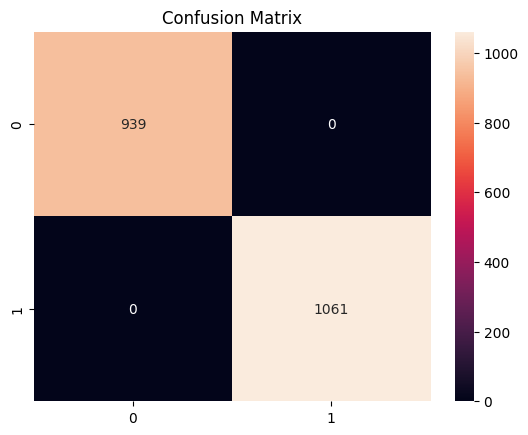

In [37]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [38]:
from sklearn.ensemble import RandomForestClassifier

models = {
    "RF Default": RandomForestClassifier(),
    "RF Depth 10": RandomForestClassifier(max_depth=10),
    "RF Complex": RandomForestClassifier(n_estimators=200, max_depth=15)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc

results

{'RF Default': 1.0, 'RF Depth 10': 1.0, 'RF Complex': 1.0}

In [39]:
importances = rf.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feat_imp.head(10)

,Feature,Importance
10,total_score,0.371194
12,average_score,0.367490
11,grade,0.138427
6,math_score,0.049422
9,science_score,0.031162
8,writing_score,0.019414
7,reading_score,0.015895
1,gender,0.003335
0,roll_no,0.003189
2,race_ethnicity,0.000207


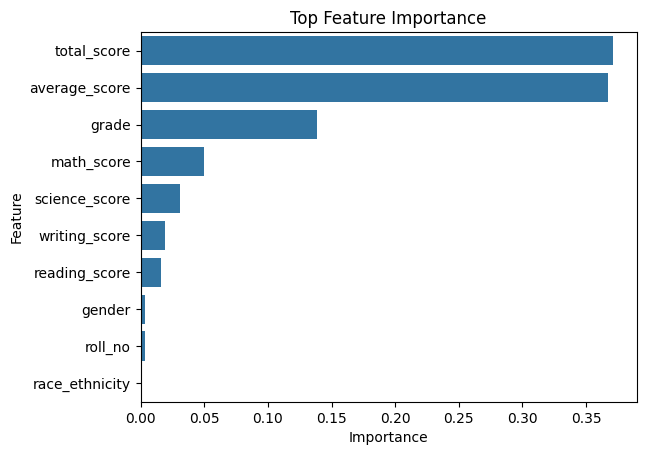

In [40]:
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10))
plt.title("Top Feature Importance")
plt.show()

In [41]:
import joblib
joblib.dump(rf, 'model_terbaik.pkl')

['model_terbaik.pkl']

In [42]:
from google.colab import files
files.download('model_terbaik.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
df_experiment = pd.DataFrame(results.items(), columns=['Model', 'Accuracy'])
df_experiment

,Model,Accuracy
0,RF Default,1.0
1,RF Depth 10,1.0
2,RF Complex,1.0
